# Chapter 08 답안 양식. 작은 데이터 분석 프로젝트 완성하기

> 이 내용을 `chapter08.ipynb`의 Markdown 셀로 작성합니다.

## 제출 정보
- 이름: 이상재
- GitHub ID: sangjae-lee97
- 작성일: 2026.09.17
- 최종 Notebook URL: https://github.com/sangjae-lee97/kant-axagent-study/blob/main/llm-data-analysis-course/chapter08/chapter08.ipynb

## 1. 프로젝트 질문
### 분석 질문
카테고리별 completed 주문 기준 금액은 어떻게 다른가?
### 분석 범위
- 주문 상태가 completed인 주문만 분석한다.
- completed 주문에 포함된 주문 항목(order_items)을 대상으로 한다.
- 상품(products)의 카테고리 정보를 연결하여 카테고리별로 집계한다.
- 카테고리별 주문 수량과 주문 금액을 비교한다.
### 사용할 데이터와 지표
order_status, category, quantity, unit_price
### 계산 기준
- `order_status == "completed"` 적용 여부:
- `line_total = quantity × unit_price` 확인 여부:

### 완료 기준
- completed 주문만 정상적으로 필터링되었는지 확인한다.
- orders와 order_items가 order_id 기준으로 정상 연결되었는지 확인한다.
- products가 product_id 기준으로 정상 연결되었는지 확인한다.
- line_total이 quantity × unit_price와 일치하는지 확인한다.
- 카테고리별 total_quantity를 계산한다.
- 카테고리별 total_sales를 계산한다.
- total_sales 기준으로 카테고리를 비교할 수 있는 결과표를 생성한다.

In [157]:
# 경로 설정
from course_utils.paths import get_project_root, get_data_dir
import pandas as pd
import numpy as np

print("프로젝트 루트 :", get_project_root())
print("데이터 폴더 :", get_data_dir())

RAW_DIR = get_project_root() / "data" / "raw"
PROCESSED_DIR = get_project_root() / "data" / "processed"
REPORT_DIR = get_project_root() / "reports"
PROJECT_ROOT = get_project_root()

프로젝트 루트 : C:\dev\kant-axagent-study\llm-data-analysis-course
데이터 폴더 : C:\dev\kant-axagent-study\llm-data-analysis-course\data


## 2. 입력 데이터와 전처리 검증
- 사용 원본 파일:
data/raw/customers.csv
data/raw/products.csv
data/raw/orders.csv
data/raw/order_items.csv
- shape, 핵심 결측/중복 결과:
customers
shape: (150, 6)
columns: ['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']
missing: 0
duplicates: 0

orders
shape: (300, 5)
columns: ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']
missing: 0
duplicates: 0

order_items
shape: (764, 5)
columns: ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']
missing: 0
duplicates: 0

prodcuts
shape: (100, 4)
columns: ['product_id', 'product_name', 'category', 'price']
missing: 0
duplicates: 0
- 전처리 전후 변화:

![입력 데이터 검증](images/step02_data_validation.png)

### 나의 해석과 판단
현재 결측치, 전체 중복 행 없음
### 한계와 추가 확인 사항
id 중복은 있을 수 있음

In [158]:
customers = pd.read_csv(get_data_dir()/"raw"/"customers.csv")
orders = pd.read_csv(get_data_dir()/"raw"/"orders.csv")
order_items = pd.read_csv(get_data_dir()/"raw"/"order_items.csv")
products = pd.read_csv(get_data_dir()/"raw"/"products.csv")

In [159]:
raw_data = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
}

In [160]:
for name, df in raw_data.items():
    print(name)
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("missing:", int(df.isna().sum().sum()))
    print("duplicates:", int(df.duplicated().sum()))
    print()

customers
shape: (150, 6)
columns: ['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']
missing: 0
duplicates: 0

orders
shape: (300, 5)
columns: ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']
missing: 0
duplicates: 0

order_items
shape: (764, 5)
columns: ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']
missing: 0
duplicates: 0

products
shape: (100, 4)
columns: ['product_id', 'product_name', 'category', 'price']
missing: 0
duplicates: 0



공통 전처리 로직

In [161]:
from src.preprocessing import (
    compare_shapes,
    preprocess_sales_data,
    validate_relationships,
)
processed_data = preprocess_sales_data(raw_data)
preprocessing_comparison = compare_shapes(
    raw_data,
    processed_data,
)
relationship_checks = validate_relationships(
    processed_data
)

## 3. PK/FK·병합 검증
### PK 결과
- 결측: 0
- 중복: 0
- PASS/FAIL: PASS

### FK 결과
- 미매칭: 0
- PASS/FAIL: PASS

### 병합 결과
- validate 관계: order_items : orders = 1 : N
- 병합 전 행 수: 764
- 병합 후 행 수: 764
- 미매칭: 0
- PASS/FAIL: PASS

### 나의 해석과 판단
전처리 완료 후 병합 성공

In [162]:
# PK 결측, 중복 확인
key_checks = []
for dataset, key in {
    "customers": "customer_id",
    "products": "product_id",
    "orders": "order_id",
    "order_items": "order_item_id",
}.items():
    df = processed_data[dataset]
    key_checks.append({
        "dataset": dataset,
        "key": key,
        "missing_count": int(df[key].isna().sum()),
        "duplicate_count": int(df[key].duplicated().sum()),
    })
key_checks = pd.DataFrame(key_checks)
display(key_checks)

,dataset,key,missing_count,duplicate_count
0,customers,customer_id,0,0
1,products,product_id,0,0
2,orders,order_id,0,0
3,order_items,order_item_id,0,0


In [163]:
# FK 미매칭 확인
missing_customer_ids = set(
    processed_data["orders"]["customer_id"].dropna()
) - set(
    processed_data["customers"]["customer_id"].dropna()
)
print("orders → customers 미매칭:", len(missing_customer_ids))

orders → customers 미매칭: 0


In [164]:
order_sales = order_items.merge(
    orders[
        [
            "order_id",
            "customer_id",
            "order_date",
            "order_status",
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one",
    indicator=True,
)
print(order_sales)

     order_item_id  order_id  product_id  quantity  unit_price  customer_id  \
0                1         1         100         3      102000          123   
1                2         1          87         5       25000          123   
2                3         1           7         3      142000          123   
3                4         1           9         3      193000          123   
4                5         2          72         4      189000           77   
..             ...       ...         ...       ...         ...          ...   
759            760       297          42         4       28000           22   
760            761       298          40         4      174000           64   
761            762       299           8         2      189000          135   
762            763       299          12         4      175000          135   
763            764       300          59         5       32000           96   

     order_date order_status _merge  
0    2026-05-

In [165]:
print("병합 전 행 수:", len(order_items))
print("병합 후 행 수:", len(order_sales))
print(
    "미매칭:",
    int(order_sales["_merge"].eq("left_only").sum()),
)

병합 전 행 수: 764
병합 후 행 수: 764
미매칭: 0


In [166]:
order_sales["line_total"] = (
    order_sales["quantity"] * order_sales["unit_price"]
)

In [167]:
# line_total 행 추가 및 검증
expected_line_total = (
    order_items["quantity"] * order_items["unit_price"]
)
line_total_matches = np.isclose(
    order_sales["line_total"],
    expected_line_total,
)
print("일치:", int(line_total_matches.sum()))
print("불일치:", int((~line_total_matches).sum()))



일치: 764
불일치: 0


In [168]:
# completetd 상태인 것만 뽑기
completed_order_sales = order_sales.loc[
    order_sales["order_status"].eq("completed")
].copy()


In [169]:
# category와 product_id 컬럼 추가하기
completed_order_sales = (
    order_sales
    .loc[order_sales["order_status"].eq("completed")]
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left",
        validate="many_to_one"
    )
    .copy()
)

In [170]:
# order_month 합치기 전 데이터 타입 확인
print(orders["order_date"].dtype)

str


In [171]:
# 날짜 데이터 타입 변환하고 월별로 그룹화
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce",
)
print("날짜 결측:", int(orders["order_date"].isna().sum()))

orders["order_month"] = orders["order_date"].dt.to_period("M")

날짜 결측: 0


In [172]:
# order_month 컬럼 추가
completed_order_sales = (
    completed_order_sales.merge(
        orders[["order_id", "order_month"]],
        on="order_id",
        how="left",
        validate="many_to_one",
    )
)

In [173]:
completed_order_sales.head()

,order_item_id,order_id,product_id,quantity,unit_price,customer_id,order_date,order_status,_merge,line_total,category,order_month
0,1,1,100,3,102000,123,2026-05-07,completed,both,306000,도서,2026-05
1,2,1,87,5,25000,123,2026-05-07,completed,both,125000,도서,2026-05
2,3,1,7,3,142000,123,2026-05-07,completed,both,426000,도서,2026-05
3,4,1,9,3,193000,123,2026-05-07,completed,both,579000,스포츠,2026-05
4,13,6,83,3,24000,87,2026-03-21,completed,both,72000,전자기기,2026-03


## 4. 핵심 EDA 결과
### 결과 1
카테고리별 completed 주문 기준 금액
- 수치/표:

In [174]:
# 카테고리별
category_sales =(
    completed_order_sales
    .groupby("category", as_index = False)
    .agg(
        total_quantity= ("quantity", sum),
        total_sales = ("line_total", sum)
    )
    .sort_values("total_sales", ascending = False)
)
category_sales

,category,total_quantity,total_sales
3,스포츠,295,31743000
5,전자기기,259,26400000
2,생활용품,272,23915000
1,뷰티,223,23383000
4,식품,133,16573000
0,도서,149,16389000
6,패션,111,10587000


- 결과 관찰: 스포츠 카테고리 판매금액이 제일 많다
- 나의 해석과 판단: 스포츠 카테고리가 수량과 판매 금액이 제일 많음
- 업무·분석적 의미: 스포츠 카테고리에 고객들이 관심이 많다
- 한계: 스포츠 카테고리도 분야가 많은데 자세한 컬럼을 알 수 없음

### 결과 2
월별 completed 주문 기준 금액과 주문 수
- 수치/표:

In [175]:
# 월별
monthly_sales = (
    completed_order_sales
    .groupby("order_month", as_index=False)
    .agg(
        total_sales= ("line_total", "sum"),
        order_count = ("order_id", "nunique"),
    )
    .sort_values("order_month")
)
monthly_sales

,order_month,total_sales,order_count
0,2025-07,5869000,8
1,2025-08,15621000,18
2,2025-09,10190000,13
3,2025-10,25766000,26
4,2025-11,8812000,12
5,2025-12,11501000,14
6,2026-01,17423000,22
7,2026-02,9749000,17
8,2026-03,13429000,14
9,2026-04,17553000,23


- 결과 관찰: 2025.10/ 2026.10/ 2026.04 월에 갑자기 판매량 늠. 
- 나의 해석과 판단: 판매량은 늘었지만 2025.10월이 판매 금액이 다른 것에 비교해서 매우 높음
- 업무·분석적 의미: 이때 비싼 물품이 많이 팔리거나 한 사람의 주문 금액이 다른 달에 비해 높음
- 한계: 위의 두 경우 중 무엇인지 파악 불가능

### 결과 3
completed 주문 기준 고객별 구매 금액
- 수치/표:


In [176]:
customer_sales = (
    completed_order_sales
    .groupby("customer_id", as_index=False)
    .agg(
        total_sales = ("line_total", "sum"),
        order_count = ("order_id", "nunique"),
    )
    .sort_values("total_sales", ascending = False)
)
customer_sales

,customer_id,total_sales,order_count
76,117,4100000,5
62,102,3996000,4
51,83,3880000,4
21,30,3590000,5
29,40,3523000,4
...,...,...,...
33,49,262000,1
10,15,252000,1
44,69,130000,2
50,80,118000,1


- 결과 관찰: 고객 판매 금액 1위는 물건을 2,3 등 대비 2배나 적게 시킴
- 나의 해석과 판단: 그 만큼 비싼 물건을 시켰음
- 업무·분석적 의미: 판매 금액도 많고, 물량도 많은 2,3등이 더 자주 사용할 것 같고 1등은 단기적 결과 일 수 있음
- 한계: 위의 결과를 확인하지 못함

## 5. Total consistency와 날짜 검증
- completed source total: 148990000.0
- category total: 148990000.0
- monthly total: 148990000.0
- customer total: 148990000.0
- 총합 일치 여부: 일치
- completed 주문 날짜 오류 건수: 0
- 날짜 오류 영향 금액: 0

### 불일치가 있었다면 원인

In [177]:
# total consistency 검증
completed_total = float(
    completed_order_sales["line_total"].sum()
)

category_total = float(
    category_sales["total_sales"].sum()
)

monthly_total = float(
    monthly_sales["total_sales"].sum()
)

customer_total = float(
    customer_sales["total_sales"].sum()
)

print("completed:", completed_total)
print("category :", category_total)
print("monthly  :", monthly_total)
print("customer :", customer_total)


print(np.isclose(completed_total, category_total))
print(np.isclose(completed_total, monthly_total))
print(np.isclose(completed_total, customer_total))

completed: 148990000.0
category : 148990000.0
monthly  : 148990000.0
customer : 148990000.0
True
True
True


In [178]:
# 날짜 검증

orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce",
)
print("날짜 결측:", int(orders["order_date"].isna().sum()))

날짜 결측: 0


## 6. 대표 시각화
![카테고리 그래프](./images/category_graph.png)
![월별 그래프](./images/monthly_graph.png)

### 그래프 선택 이유
매출 분석에 가장 도움이 될 것 같아서
### 그래프와 원본 집계값 일치 여부
일치
### 그래프에서 직접 관찰한 사실
월별 그래프에서 매출의 주기가 있고 현재 엄청난 하락세임
### 그래프만으로 말할 수 없는 것
현재 매출이 어느 부분에서 떨어졌는지, 원인이 무엇인지 파악 불가능

In [179]:
# 한글과 마이너스 폰트 바꾸기
from matplotlib import font_manager
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ["Malgun Gothic", "AppleGothic", "Apple SD Gothic Neo", "Noto Sans CJK KR", "NanumGothic"]

import matplotlib.pyplot as plt

korean_font = next(
    (name for name in font_candidates if name in installed_fonts), None
)

print("선택된 한글 폰트: ", korean_font)

if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

선택된 한글 폰트:  Malgun Gothic


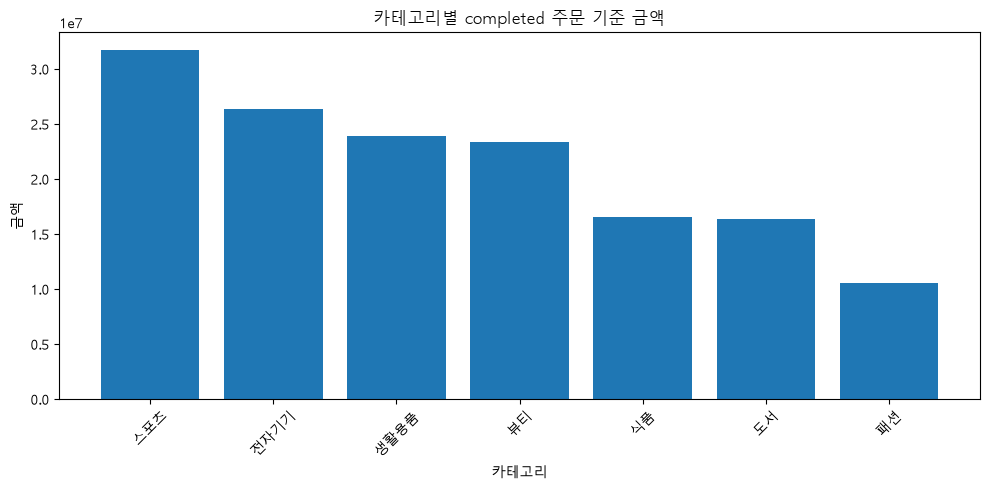

In [180]:
# 카테고리를 막대그래프로 표시

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category_sales["category"],
    category_sales["total_sales"],
)
ax.set_title("카테고리별 completed 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")
ax.set_ylim(bottom=0)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


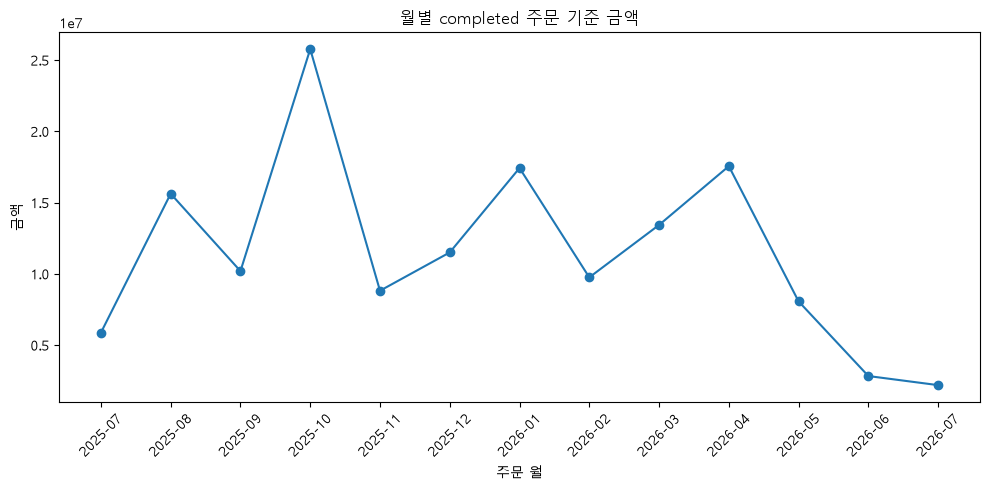

In [181]:
# 그래프용으로 월을 문자열로 변환
monthly_sales["order_month"] = monthly_sales["order_month"].astype(str)

# 월별 금액은 선그래프로 표시
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_sales"],
    marker="o",
)
ax.set_title("월별 completed 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


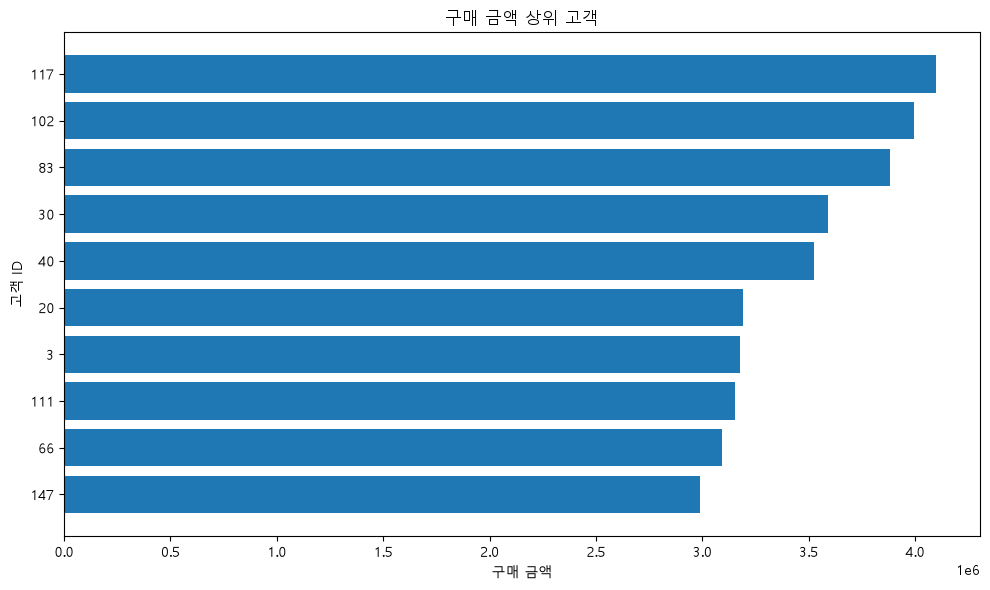

In [184]:
# 상위 익명 고객 구매 금액은 가로 막대 그래프로 표시

# 구매 금액 상위 10명
top_ten_customers = (
    customer_sales
    .sort_values("total_sales", ascending=False)
    .head(10)
    .copy()
)

# 가로 막대그래프
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_ten_customers["customer_id"].astype(str),
    top_ten_customers["total_sales"],
)

ax.set_title("구매 금액 상위 고객")
ax.set_xlabel("구매 금액")
ax.set_ylabel("고객 ID")

# 가장 큰 금액이 위쪽에 오도록
ax.invert_yaxis()

fig.tight_layout()
plt.show()

## 7. 개인정보 검증
- 공개 고객 CSV 컬럼: customer_id
- 원본 `customer_id` 포함 여부: no
- 이름/이메일/전화번호/주소 포함 여부: no
- 익명 라벨 방식: 공개 가능한 city만 연결하고, 구매 금액 순서대로 순위 기반 익명 라벨 생성
- PASS/FAIL: PASS

### 나의 판단
좋은거 같음

In [185]:

customer_public = customer_sales.merge(
    processed_data["customers"][["customer_id", "city"]],
    on="customer_id",
    how="left",
    validate="one_to_one",
)

customer_public = customer_public.sort_values(
    "total_sales",
    ascending=False,
).reset_index(drop=True)

customer_public["customer_label"] = [
    f"Customer {rank:02d}"
    for rank in range(1, len(customer_public) + 1)
]


In [188]:

customer_public["avg_order_value"] = (
    customer_public["total_sales"]
    / customer_public["order_count"]
)

customer_public = customer_public[
    [
        "customer_label",
        "city",
        "total_sales",
        "order_count",
        "avg_order_value",
    ]
]
display(customer_public.head(10))


,customer_label,city,total_sales,order_count,avg_order_value
0,Customer 01,성남,4100000,5,820000.0
1,Customer 02,고양,3996000,4,999000.0
2,Customer 03,수원,3880000,4,970000.0
3,Customer 04,서울,3590000,5,718000.0
4,Customer 05,서울,3523000,4,880750.0
5,Customer 06,인천,3191000,2,1595500.0
6,Customer 07,성남,3178000,2,1589000.0
7,Customer 08,광주,3153000,3,1051000.0
8,Customer 09,서울,3093000,4,773250.0
9,Customer 10,부산,2990000,2,1495000.0


In [189]:
forbidden = {
    "customer_id",
    "name",
    "email",
    "phone",
    "address",
}
privacy_violation = sorted(
    forbidden.intersection(customer_public.columns)
)
print("공개 결과 금지 컬럼:", privacy_violation)
if privacy_violation:
    raise ValueError("Privacy Gate 실패")
print("Privacy Gate: PASS")


공개 결과 금지 컬럼: []
Privacy Gate: PASS


## 8. 최종 Validation
`reports/ch08_project_validation.csv`의 결과를 요약합니다.

| 검증 항목                                  | 결과   | 내가 확인한 근거                                                                                       |
| -------------------------------------- | ---- | ----------------------------------------------------------------------------------------------- |
| pk_integrity                           | PASS | 각 테이블의 PK 컬럼에 결측치와 중복값이 없는지 확인                                                                  |
| fk_integrity                           | PASS | `orders.customer_id`, `order_items.order_id`, `order_items.product_id`가 참조 테이블의 PK와 정상 연결되는지 확인 |
| merge_checks_pass                      | PASS | `validate="many_to_one"` 등을 사용한 merge가 오류 없이 수행되고 병합 관계가 예상과 일치하는지 확인                           |
| line_total_consistency                 | PASS | `line_total`이 `quantity × unit_price` 계산 결과와 일치하는지 확인                                           |
| completed_total_consistency            | PASS | completed 주문만 필터링한 금액 합계와 최종 completed 집계 금액이 일치하는지 확인                                          |
| category_sales_ratio_pct_sum           | PASS | 카테고리별 completed 주문 금액 비율의 합계가 100%가 되는지 확인                                                      |
| completed_rows_with_invalid_order_date | PASS | completed 주문 중 유효하지 않은 `order_date`가 없는지 확인                                                     |
| public_customer_columns_safe           | PASS | 공개용 고객 데이터에 직접 식별 가능한 고객 정보가 포함되지 않았는지 확인                                                       |
### FAIL이 있었다면 수정 내용

## 9. LLM 활용 기록

- 사용 여부: 사용

- 사용 목적:
  상위 고객 구매 금액을 시각화할 때 실제 customer_id를 그대로 노출하지 않고 익명화하여 표현하는 방법을 확인하기 위해 사용함.

- Prompt 요약:
  customer_sales 데이터를 이용해 상위 고객의 구매 금액을 가로 막대그래프로 표시하고 싶으며, 고객 정보를 익명화하는 방법을 질문함.

- 제안 요약:
  상위 10명의 고객 데이터를 추출한 뒤 `anonymous_customer` 컬럼을 새로 만들어 `고객 1`, `고객 2`와 같은 익명 라벨을 부여하고, 해당 컬럼을 가로 막대그래프의 y축에 사용하도록 제안받음.

- 반영/수정/보류:
  익명화 방식의 목적은 적절하다고 판단했지만, 아직 배우지 않은 방식이라 최종 코드에는 반영하지 않고 보류함. 대신 기존 `customer_id`를 문자열로 변환해 범주형 축으로 사용하는 방식으로 수정함.

- 사람이 검증한 근거:
  `customer_sales`가 `total_sales` 기준 내림차순으로 정렬되어 있는지 확인하고, `head(10)`으로 상위 10명만 추출되는 것을 직접 확인함. 또한 `customer_id.astype(str)`를 사용했을 때 고객 ID가 연속적인 숫자축이 아니라 각각의 범주로 표시되는 것을 그래프로 확인함.

## 10. 프로젝트 재현 확인
- `python scripts/run_midterm_project.py` 실행 여부: 예
- 재실행 결과:
(.venv) PS C:\dev\kant-axagent-study\llm-data-analysis-course> python scripts/run_midterm_project.py
8장 중간 프로젝트 완료

[데이터 개요]
    dataset  rows  columns  missing_values  duplicated_rows
  customers   150        6               0                0
   products   100        4               0                0
     orders   300        5               0                0
order_items   764        5               0                0

[전처리 전후 비교]
    dataset  rows_raw  columns_raw  rows_processed  columns_processed
  customers       150            6             150                  6
order_items       764            5             764                  6
     orders       300            5             300                  7
   products       100            4             100                  4

[PK 검증]
    dataset           key  missing_count  duplicate_count status detail
  customers   customer_id              0                0   PASS       
   products    product_id              0                0   PASS       
     orders      order_id              0                0   PASS       
order_items order_item_id              0                0   PASS       

[FK 검증]
                                               check  invalid_count status
  orders.customer_id exists in customers.customer_id              0   PASS
      order_items.order_id exists in orders.order_id              0   PASS
order_items.product_id exists in products.product_id              0   PASS

[병합 검증]
                  merge    validate  before_rows  after_rows  row_count_preserved  unmatched_count status
      order_id → orders many_to_one          764         764                 True                0   PASS
  product_id → products many_to_one          474         474                 True                0   PASS
customer_id → customers  one_to_one          100         100                 True                0   PASS

[line_total 검증]
                             check   source  row_count  mismatch_count status
line_total = quantity × unit_price existing        764               0   PASS

[전체 주문 상세 금액과 completed 주문 기준 금액]
                 scope      amount  detail_rows
       all_order_items 255610000.0          764
 completed_order_items 148990000.0          474
excluded_non_completed 106620000.0          290

[Total consistency]
          source      amount  difference_from_completed  matches_completed status
completed_source 148990000.0                        0.0               True   PASS
        category 148990000.0                        0.0               True   PASS
         monthly 148990000.0                        0.0               True   PASS
        customer 148990000.0                        0.0               True   PASS

[최종 Validation]
                                 check                value             expected status
                          pk_integrity             all PASS             all PASS   PASS
                          fk_integrity                    0                    0   PASS
                     merge_checks_pass             all PASS             all PASS   PASS
                line_total_consistency                    0                    0   PASS
           completed_total_consistency            all match            all match   PASS
          category_sales_ratio_pct_sum                100.0                100.0   PASS
completed_rows_with_invalid_order_date                    0                    0   PASS
          public_customer_columns_safe no forbidden columns no forbidden columns   PASS

[카테고리별 completed 주문 기준 금액 상위 5개]
category  total_quantity  total_sales  sales_ratio
     스포츠             295     31743000        21.31
    전자기기             259     26400000        17.72
    생활용품             272     23915000        16.05
      뷰티             223     23383000        15.69
      식품             133     16573000        11.12

[월별 completed 주문 기준 금액]
order_month  total_sales  order_count  avg_order_value
    2025-07      5869000            8         733625.0
    2025-08     15621000           18         867833.0
    2025-09     10190000           13         783846.0
    2025-10     25766000           26         991000.0
    2025-11      8812000           12         734333.0
    2025-12     11501000           14         821500.0
    2026-01     17423000           22         791955.0
    2026-02      9749000           17         573471.0
    2026-03     13429000           14         959214.0
    2026-04     17553000           23         763174.0
    2026-05      8063000           11         733000.0
    2026-06      2826000            4         706500.0
    2026-07      2188000            2        1094000.0

[저장된 결과표]
- reports\ch08_dataset_summary.csv
- reports\ch08_preprocessing_comparison.csv
- reports\ch08_key_duplicate_checks.csv
- reports\ch08_relationship_checks.csv
- reports\ch08_merge_checks.csv
- reports\ch08_line_total_check.csv
- reports\ch08_date_checks.csv
- reports\ch08_amount_scope_summary.csv
- reports\ch08_total_consistency_check.csv
- reports\ch08_project_validation.csv
- reports\ch08_category_sales.csv
- reports\ch08_monthly_sales.csv
- reports\ch08_customer_sales.csv
- reports\ch08_order_status_summary.csv
- reports\ch08_interpretation_notes.csv

[저장된 그래프]
- reports\figures\ch08_category_sales.png
- reports\figures\ch08_monthly_sales.png
- reports\figures\ch08_top_customers.png

[최종 보고서] reports\ch08_midterm_report.md
(.venv) PS C:\dev\kant-axagent-study\llm-data-analysis-course> 

- Notebook과 핵심 수치 일치 여부: 확인 필요
  - 스크립트 내부에서는 completed 주문 기준 금액 148,990,000원이 카테고리별, 월별, 고객별 집계 결과와 모두 일치함.
  - 다만 Notebook의 최종 출력 수치와 직접 비교한 결과 일치 확인 완료
- 생성된 핵심 Evidence 파일 확인 여부: 확인 완료
  - 검증 결과 CSV, 분석 결과 CSV, 그래프 이미지, 최종 보고서가 정상적으로 생성됨.
  - `ch08_project_validation.csv`의 모든 검증 항목이 PASS임.

![재실행 결과](images/step06_reproduce.png)

### 나의 해석과 판단
같은 데이터와 같은 코드로 다시 실행했을 때 같은 결과를 얻을 수 있어야 분석 결과를 신뢰할 수 있기 때문


## 11. 최종 프로젝트 요약

### 핵심 인사이트 3개

1. completed 주문 기준 전체 금액은 148,990,000원이었으며, 카테고리별로는 스포츠가 31,743,000원으로 가장 높은 금액을 기록했다.

2. 월별 completed 주문 금액은 일정하지 않고 변동이 있었으며, 2025년 10월이 25,766,000원으로 가장 높았다. 반면 일부 월은 주문 건수와 금액이 상대적으로 낮아 월별 차이가 존재했다.

3. 고객별 completed 주문 금액을 집계한 결과 일부 고객에게 구매 금액이 집중되는 현상을 확인할 수 있었으며, 고객별 구매 금액과 주문 횟수를 함께 비교할 필요가 있음을 확인했다.

### 가장 중요한 업무·분석적 의미

단순히 전체 매출만 보는 것보다 카테고리, 월, 고객 단위로 나누어 분석하면 어떤 상품군과 시점, 고객군이 completed 주문 금액에 더 크게 기여하는지 확인할 수 있다. 특히 카테고리별 금액과 월별 변화를 함께 보면 판매 전략이나 프로모션 시점을 결정할 때 참고할 수 있는 기초 자료로 활용할 수 있다.

또한 모든 금액 집계가 동일한 completed 기준 금액 148,990,000원과 일치하는 것을 검증하여, 분석 결과가 서로 다른 집계 과정에서도 일관되게 유지되는 것을 확인했다.

### 현재 분석의 한계

현재 데이터는 약 1년 정도의 제한된 기간과 비교적 적은 수의 고객, 주문 데이터를 기반으로 하므로 장기적인 추세나 계절성을 일반화하기에는 한계가 있다.

또한 이번 분석은 주문 금액과 주문 건수 중심으로 진행했기 때문에 할인, 원가, 이익률, 재구매 여부와 같은 정보는 포함하지 않았다.

마지막으로 카테고리별 또는 고객별 금액 차이가 발생한 원인을 설명할 수 있는 추가 변수에 대한 분석은 수행하지 않았으므로, 현재 결과만으로 특정 원인을 단정할 수 없다.

### 다음 분석 제안

1. 월별·카테고리별 금액을 함께 분석하여 특정 시기에 어떤 카테고리의 판매가 증가하거나 감소하는지 확인한다.

2. 고객별 주문 횟수, 구매 금액, 평균 주문 금액을 이용해 반복 구매 고객과 고액 구매 고객의 특징을 비교한다.

3. 주문 상태, 결제 방법, 고객 연령·지역 등의 변수를 추가로 분석하여 completed 주문 금액과 관련된 패턴이 있는지 확인한다.

## 최종 체크

- [x] 질문과 지표가 연결됩니다.
- [x] 원본 데이터에서 다시 시작했습니다.
- [x] PK/FK·병합 검증 근거가 있습니다.
- [x] `line_total` 계산 관계를 확인했습니다.
- [x] 금액성 분석은 completed 범위를 사용했습니다.
- [x] category/month/customer 총합이 source total과 일치합니다.
- [x] 날짜 오류를 확인했습니다.
- [x] 공개 고객 결과에서 원본 ID와 직접 식별정보를 제거했습니다.
- [x] 대표 그래프와 원본 집계값을 비교했습니다.
- [x] 원인 과대 해석이 없습니다.
- [x] 최종 Validation이 모두 PASS입니다.
- [x] 전체 프로젝트를 재실행했습니다.
- [x] 한계와 다음 분석을 작성했습니다.
- [x] 최종 Notebook URL을 제출합니다.